<a href="https://www.kaggle.com/code/sawaira89khan/transfer-learning-resnet50?scriptVersionId=336697710" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input   
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist

# MNIST uses integer labels 0–9 representing the handwritten digits
CLASS_NAMES = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
NUM_CLASSES = len(CLASS_NAMES)   # 10

# ── Load ─────────────────────────────────────────────────────────────────────
# mnist.load_data() downloads (~11MB) and caches in ~/.keras/datasets/.
# Returns:
#   x_train : shape (60000, 28, 28)     dtype uint8  pixel values [0, 255]
#   y_train : shape (60000,)            dtype uint8  class index  [0, 9]
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

print("MNIST Dataset Loaded")
print("=" * 48)
print(f"  Training images  : {x_train_raw.shape[0]:,}")
print(f"  Test images      : {x_test_raw.shape[0]:,}")
print(f"  Image dimensions : {x_train_raw.shape[1:]}  (H × W)")
print(f"  Pixel dtype      : {x_train_raw.dtype}")
print(f"  Pixel range      : [{x_train_raw.min()}, {x_train_raw.max()}]")
print(f"  Number of classes: {NUM_CLASSES}")
print()
print("  Class distribution (train):")

for i, name in enumerate(CLASS_NAMES):
    # Flattening comparison because MNIST labels are 1D arrays, unlike CIFAR's 2D column vector
    count = np.sum(y_train_raw.flatten() == i)
    bar = '█' * (count // 250)  # Adjusted scaling factor slightly since MNIST has more training samples
    print(f"    [{i}] Digit {name:7s} : {bar} {count:,}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset Loaded
  Training images  : 60,000
  Test images      : 10,000
  Image dimensions : (28, 28)  (H × W)
  Pixel dtype      : uint8
  Pixel range      : [0, 255]
  Number of classes: 10

  Class distribution (train):
    [0] Digit 0       : ███████████████████████ 5,923
    [1] Digit 1       : ██████████████████████████ 6,742
    [2] Digit 2       : ███████████████████████ 5,958
    [3] Digit 3       : ████████████████████████ 6,131
    [4] Digit 4       : ███████████████████████ 5,842
    [5] Digit 5       : █████████████████████ 5,421
    [6] Digit 6       : ███████████████████████ 5,918
    [7] Digit 7       : █████████████████████████ 6,265
    [8] Digit 8       : ███████████████████████ 5,851
    [9] Digit 9       : ███████████████████████ 5,949


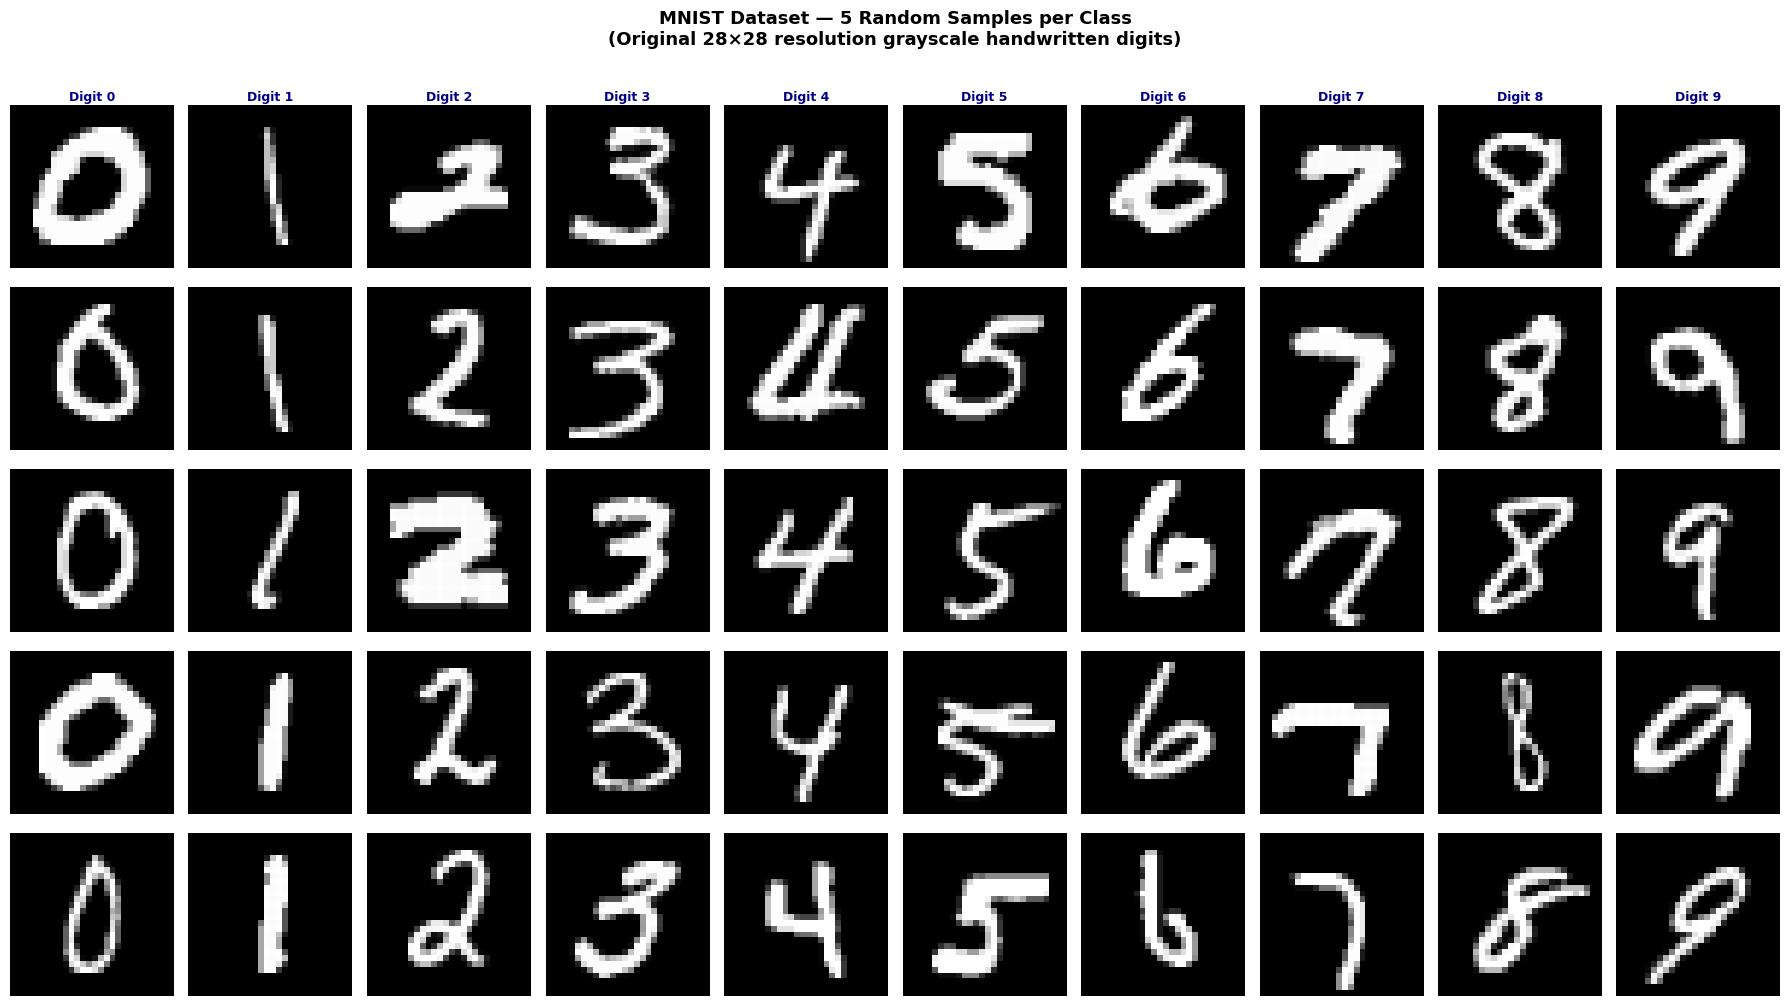

Pixel statistics (raw uint8, training set):
  Grayscale Intensity: mean=33.32  std=78.57  min=0  max=255


In [3]:
import matplotlib.pyplot as plt

# 5 rows (samples) x 10 columns (digits 0-9)
fig, axes = plt.subplots(5, 10, figsize=(18, 10))
fig.suptitle(
    'MNIST Dataset — 5 Random Samples per Class\n'
    '(Original 28×28 resolution grayscale handwritten digits)',
    fontsize=13, fontweight='bold', y=1.01)

for cls_idx in range(NUM_CLASSES):
    # Find all indices belonging to the current digit class
    class_indices = np.where(y_train_raw.flatten() == cls_idx)[0]
    chosen        = np.random.choice(class_indices, 5, replace=False)
    
    for row, img_idx in enumerate(chosen):
        ax = axes[row, cls_idx]
        # cmap='gray' is critical for correct grayscale visualization
        ax.imshow(x_train_raw[img_idx], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(f"Digit {CLASS_NAMES[cls_idx]}", fontsize=9, fontweight='bold',
                         color='darkblue', pad=3)

plt.tight_layout() 
plt.show()

# ── Pixel statistics (Single Channel Grayscale) ──────────────────────────────────
#  MNIST has no RGB color channels; we calculate statistics across the entire 2D dataset.
print("Pixel statistics (raw uint8, training set):")
pixel_data = x_train_raw.astype(np.float32)

print(f"  Grayscale Intensity: mean={pixel_data.mean():.2f}  "
      f"std={pixel_data.std():.2f}  "
      f"min={pixel_data.min():.0f}  max={pixel_data.max():.0f}")

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURATION HYPERPARAMETERS ───────────────────────────────────────────
BATCH_SIZE = 128
EPOCHS = 20
IMG_SIZE = 28  # MNIST is 28x28
NUM_CLASSES = 10

# High-performance pipeline tuning
AUTOTUNE = tf.data.AUTOTUNE

print(f"Pipeline Configured | Batch Size: {BATCH_SIZE} | Target Size: {IMG_SIZE}x{IMG_SIZE}x1")

Pipeline Configured | Batch Size: 128 | Target Size: 28x28x1


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURATION HYPERPARAMETERS ───────────────────────────────────────────
BATCH_SIZE = 128
EPOCHS = 20
IMG_SIZE = 64 
AUTOTUNE = tf.data.AUTOTUNE

print(f"ResNet-50 Pipeline Configured | Target Size: {IMG_SIZE}x{IMG_SIZE}x3")

ResNet-50 Pipeline Configured | Target Size: 64x64x3


In [6]:
# 1. Expand dimensions to (H, W, 1) and cast to float32
x_train = np.expand_dims(x_train_raw, axis=-1).astype(np.float32)
x_test  = np.expand_dims(x_test_raw, axis=-1).astype(np.float32)

# 2. One-Hot Encoding
y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_raw, NUM_CLASSES)

In [7]:
# ── FIX: Native TensorFlow Pipeline Processing Functions ─────────────────────

def prepare_resnet_input(image, label, is_training=True):
    """
    Transforms grayscale 28x28 MNIST tensors into 64x64x3 tensors 
    compatible with ResNet-50 using native graph-safe operations.
    """
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    image = tf.image.grayscale_to_rgb(image)
    
    image = tf.keras.applications.resnet50.preprocess_input(image)
    
    # 4. Safe Data Augmentation (Using Graph-compatible tf.image operations)
    if is_training:

        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        
        # Native safe crop & pad resize to simulate minor zooms
        image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 4, IMG_SIZE + 4)
        image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])

    return image, label

In [8]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# Re-build your Train Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=60000)
train_dataset = train_dataset.map(lambda x, y: prepare_resnet_input(x, y, is_training=True),
                                  num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

print("✅ 'train_dataset' is now defined and ready!")

I0000 00:00:1784552393.820957      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ 'train_dataset' is now defined and ready!


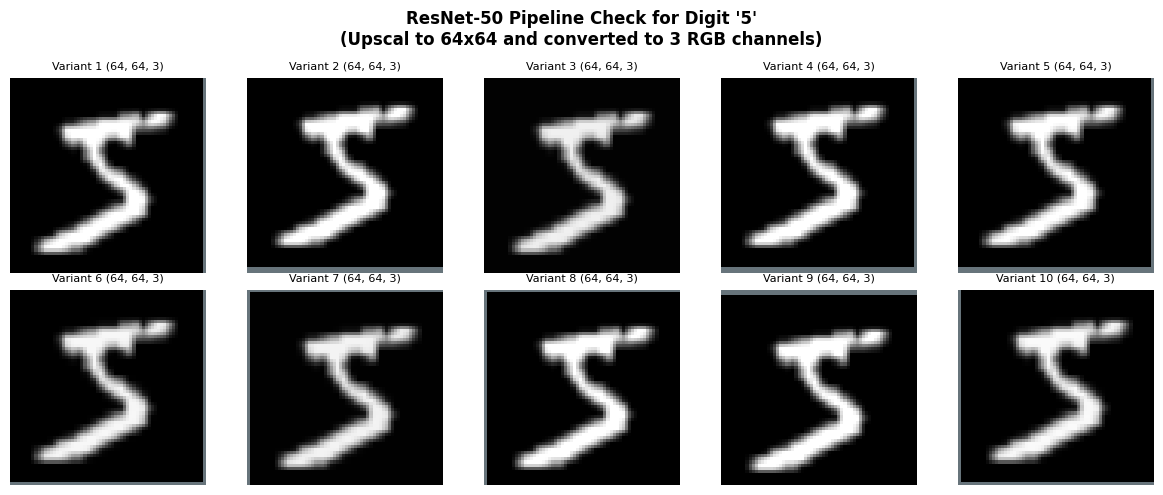

In [9]:
# Grab a single batch from our training pipeline
image_batch, label_batch = next(iter(train_dataset))

# Take a sample to see how it transforms multiple times
sample_img = x_train[0]
true_label = np.argmax(y_train[0])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f"ResNet-50 Pipeline Check for Digit '{true_label}'\n(Upscal to {IMG_SIZE}x{IMG_SIZE} and converted to 3 RGB channels)", 
             fontsize=12, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    ax = axes[row, col]
    
    # Process a single image tensor through our training function
    img_tensor, _ = prepare_resnet_input(tf.convert_to_tensor(sample_img), tf.convert_to_tensor(y_train[0]), is_training=True)
    img_numpy = img_tensor.numpy()
    
    # Reversing ResNet's ImageNet mean centering adjustment solely for visual sanity check
    img_numpy[..., 0] += 103.939
    img_numpy[..., 1] += 116.779
    img_numpy[..., 2] += 123.68
    img_numpy = np.clip(img_numpy, 0, 255).astype('uint8')
    
    # Show as an RGB image (matplotlib automatically handles 3 channels)
    ax.imshow(img_numpy)
    ax.axis('off')
    ax.set_title(f"Variant {i+1} {img_numpy.shape}", fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load ResNet50 pre-trained on ImageNet without its top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model layers so they don't change during Phase 1
base_model.trainable = False

# Construct a new classification head for our 10 digit classes
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Flattens spatial dimensions cleanly
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Show structural summary & parameter count
model.summary()

# Inspect layer names to locate Phase 2 target blocks
print("\nSample of ResNet-50 Layer Names:")
for i, layer in enumerate(base_model.layers[-15:]):  # Looking at the tail end
    print(f"Layer {i}: {layer.name} | Trainable: {layer.trainable}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Sample of ResNet-50 Layer Names:
Layer 0: conv5_block2_2_relu | Trainable: False
Layer 1: conv5_block2_3_conv | Trainable: False
Layer 2: conv5_block2_3_bn | Trainable: False
Layer 3: conv5_block2_add | Trainable: False
Layer 4: conv5_block2_out | Trainable: False
Layer 5: conv5_block3_1_conv | Trainable: False
Layer 6: conv5_block3_1_bn | Trainable: False
Layer 7: conv5_block3_1_relu | Trainable: False
Layer 8: conv5_block3_2_conv | Trainable: False
Layer 9: conv5_block3_2_bn | Trainable: False
Layer 10: conv5_block3_2_relu | Trainable: False
Layer 11: conv5_block3_3_conv | Trainable: False
Layer 12: conv5_block3_3_bn | Trainable: False
Layer 13: conv5_block3_add | Trainable: False
Layer 14: conv5_block3_out | Trainable: False


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

# 1. Early Stopping to save time/prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. Model Checkpoint to save the best model weights
checkpoint = ModelCheckpoint('best_resnet50_mnist.keras', monitor='val_accuracy', save_best_only=True)

# 3. Simple custom step learning rate scheduler
def lr_decay(epoch):
    initial_lr = 1e-3
    if epoch > 5:
        return initial_lr * 0.1
    return initial_lr

lr_scheduler = LearningRateScheduler(lr_decay)

callbacks_phase1 = [early_stop, checkpoint, lr_scheduler]

In [13]:
# ── FIX: Map first, Batch second ──────────────────────────────────────────
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# 1. Build Train Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=60000)

# FIX: Map over individual elements (3D images) BEFORE grouping them into batches
train_dataset = train_dataset.map(lambda x, y: prepare_resnet_input(x, y, is_training=True),
                                  num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# 2. Build Test/Validation Pipeline
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(lambda x, y: prepare_resnet_input(x, y, is_training=False),
                                 num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Pipelines successfully rebuilt with correct execution order!")

Pipelines successfully rebuilt with correct execution order!


In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Phase 1: Feature Extraction...")
history_phase1 = model.fit(train_dataset, 
                           validation_data=test_dataset, 
                           epochs=6, 
                           callbacks=callbacks_phase1)

Starting Phase 1: Feature Extraction...
Epoch 1/6
  6/469 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1696 - loss: 3.2078

I0000 00:00:1784552413.613981      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.8736 - loss: 0.3990 - val_accuracy: 0.9459 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9388 - loss: 0.1900 - val_accuracy: 0.9640 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9464 - loss: 0.1650 - val_accuracy: 0.9597 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9521 - loss: 0.1471 - val_accuracy: 0.9655 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9569 - loss: 0.1318 - val_accuracy: 0.9675 - val_loss: 0.1059 - learning_rate: 0.0010
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9576 - loss: 0.1275 - val_accuracy: 0.9590 - val_loss: 0.1332 - learning_rate: 0.0010


In [15]:
# Unfreeze the base model completely
base_model.trainable = True

# Refreeze everything up to the final convolutional block group (conv5_x)
# ResNet-50 has 175 layers total. We will freeze everything before layer 143.
for layer in base_model.layers[:143]:
    layer.trainable = False

# Verify the unfreezing strategy worked
print("Trainable layers updated. Recompiling with low Learning Rate...")

# Use a significantly smaller learning rate for fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Run Fine-Tuning
history_phase2 = model.fit(train_dataset, 
                           validation_data=test_dataset, 
                           epochs=6, 
                           callbacks=[early_stop, checkpoint])

Trainable layers updated. Recompiling with low Learning Rate...
Epoch 1/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.8946 - loss: 0.3908 - val_accuracy: 0.9595 - val_loss: 0.1399
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9539 - loss: 0.1531 - val_accuracy: 0.9731 - val_loss: 0.0954
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9673 - loss: 0.1076 - val_accuracy: 0.9766 - val_loss: 0.0806
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9738 - loss: 0.0844 - val_accuracy: 0.9790 - val_loss: 0.0684
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9792 - loss: 0.0675 - val_accuracy: 0.9826 - val_loss: 0.0602
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9826 - loss: 0.0556 - val_accuracy: 0.9834 - val_loss: 0.0555


79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step


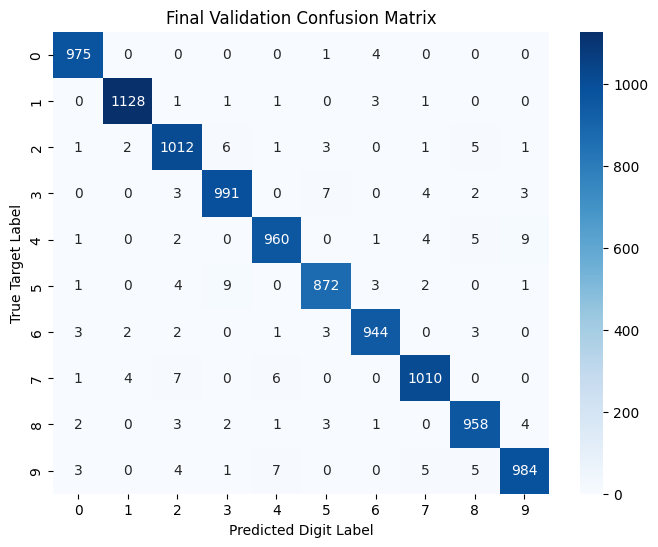

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predict labels on the validation set
y_pred_raw = model.predict(test_dataset)
y_pred = np.argmax(y_pred_raw, axis=1)
y_true = y_test_raw  # The flat original integer array

# 2. Build the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Visualize using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Final Validation Confusion Matrix')
plt.xlabel('Predicted Digit Label')
plt.ylabel('True Target Label')
plt.show()

# 4. Show summary report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_one_of_each_digit(model, test_dataset):
    """
    Finds exactly one example for each digit (0-9) from the test dataset
    and plots them sequentially with their true vs. predicted probabilities.
    """
    mnist_classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
    
    # Dictionaries to store exactly one image/label tensor per unique digit
    found_images = {}
    found_labels = {}
    
    # 1. Iterate through the dataset pipeline to gather our 10 unique examples
    for images, labels in test_dataset:
        images_np = images.numpy()
        
        # Decode one-hot encoded label vectors back to class integers if necessary
        if len(labels.shape) > 1 and labels.shape[1] > 1:
            lbls_np = np.argmax(labels.numpy(), axis=1)
        else:
            lbls_np = labels.numpy()
            
        for i in range(len(lbls_np)):
            digit = int(lbls_np[i])
            # If we haven't collected this digit yet, save it
            if digit not in found_images:
                found_images[digit] = images_np[i]
                found_labels[digit] = digit
                
        # Break early once we successfully have exactly one of each digit (0-9)
        if len(found_images) == 10:
            break

    # 2. Sort keys so the plot runs strictly in sequential order from 0 to 9
    sorted_digits = sorted(found_images.keys())
    
    # Prepare arrays for inference matching the 0-9 sequence
    ordered_images = np.array([found_images[d] for d in sorted_digits])
    
    # Generate model probability predictions for these 10 unique targets
    preds_probs = model.predict(ordered_images)

    # 3. Setup the 10-row plot environment
    fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(14, 40))
    fig.suptitle('ResNet50 Transfer Learning — One Example Per Digit (0-9)\n'
                 'Left: Handwritten Target  |  Right: Model Class Probability Distribution', 
                 fontsize=16, fontweight='bold', color='#2c3e50', y=0.99)

    # 4. Generate the visualization layers
    for idx, digit in enumerate(sorted_digits):
        img = ordered_images[idx]
        true_idx = digit
        prob_dist = preds_probs[idx]
        pred_idx = int(np.argmax(prob_dist))
        pred_conf = prob_dist[pred_idx] * 100

        ax_img = axes[idx, 0]
        ax_bar = axes[idx, 1]

        # Rescale the image pixel range safely to standard [0, 1] format for visualization
        if img.min() < 0:
            img = (img - img.min()) / (img.max() - img.min())

        ax_img.imshow(img)
        ax_img.axis('off')

        # Text evaluations matching prediction accuracy
        is_correct = (pred_idx == true_idx)
        status_text = "✓ CORRECT" if is_correct else "✗ WRONG"
        title_color = '#27ae60' if is_correct else '#c0392b'

        ax_img.text(0.5, 1.2, f"{status_text}\nTrue Digit: {mnist_classes[true_idx]}\nPred Digit: {mnist_classes[pred_idx]} ({pred_conf:.1f}%)",
                    transform=ax_img.transAxes, ha='center', va='center', 
                    color=title_color, fontweight='bold', fontsize=12)

        # ── Draw Numeric Horizontal Bar Chart ────────────────────────────────
        y_pos = np.arange(10)
        bar_colors = ['#bdc3c7'] * 10
        
        if is_correct:
            bar_colors[pred_idx] = '#2ecc71'  # Vibrant Green for right answers
        else:
            bar_colors[pred_idx] = '#e74c3c'  # Crimson Red for errors
            bar_colors[true_idx] = '#2ecc71'  # Highlight correct target in green anyway

        bars = ax_bar.barh(y_pos, prob_dist, color=bar_colors, edgecolor='grey', height=0.6)
        
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(mnist_classes, fontsize=11, fontweight='bold')
        ax_bar.set_xlim([0.0, 1.05])
        ax_bar.grid(axis='x', linestyle=':', alpha=0.5)

        # Print confidence value percentage markings next to active prediction bars
        for bar in bars:
            width = bar.get_width()
            if width > 0.01:
                ax_bar.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                            f'{width*100:.1f}%', va='center', ha='left', 
                            fontsize=10, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


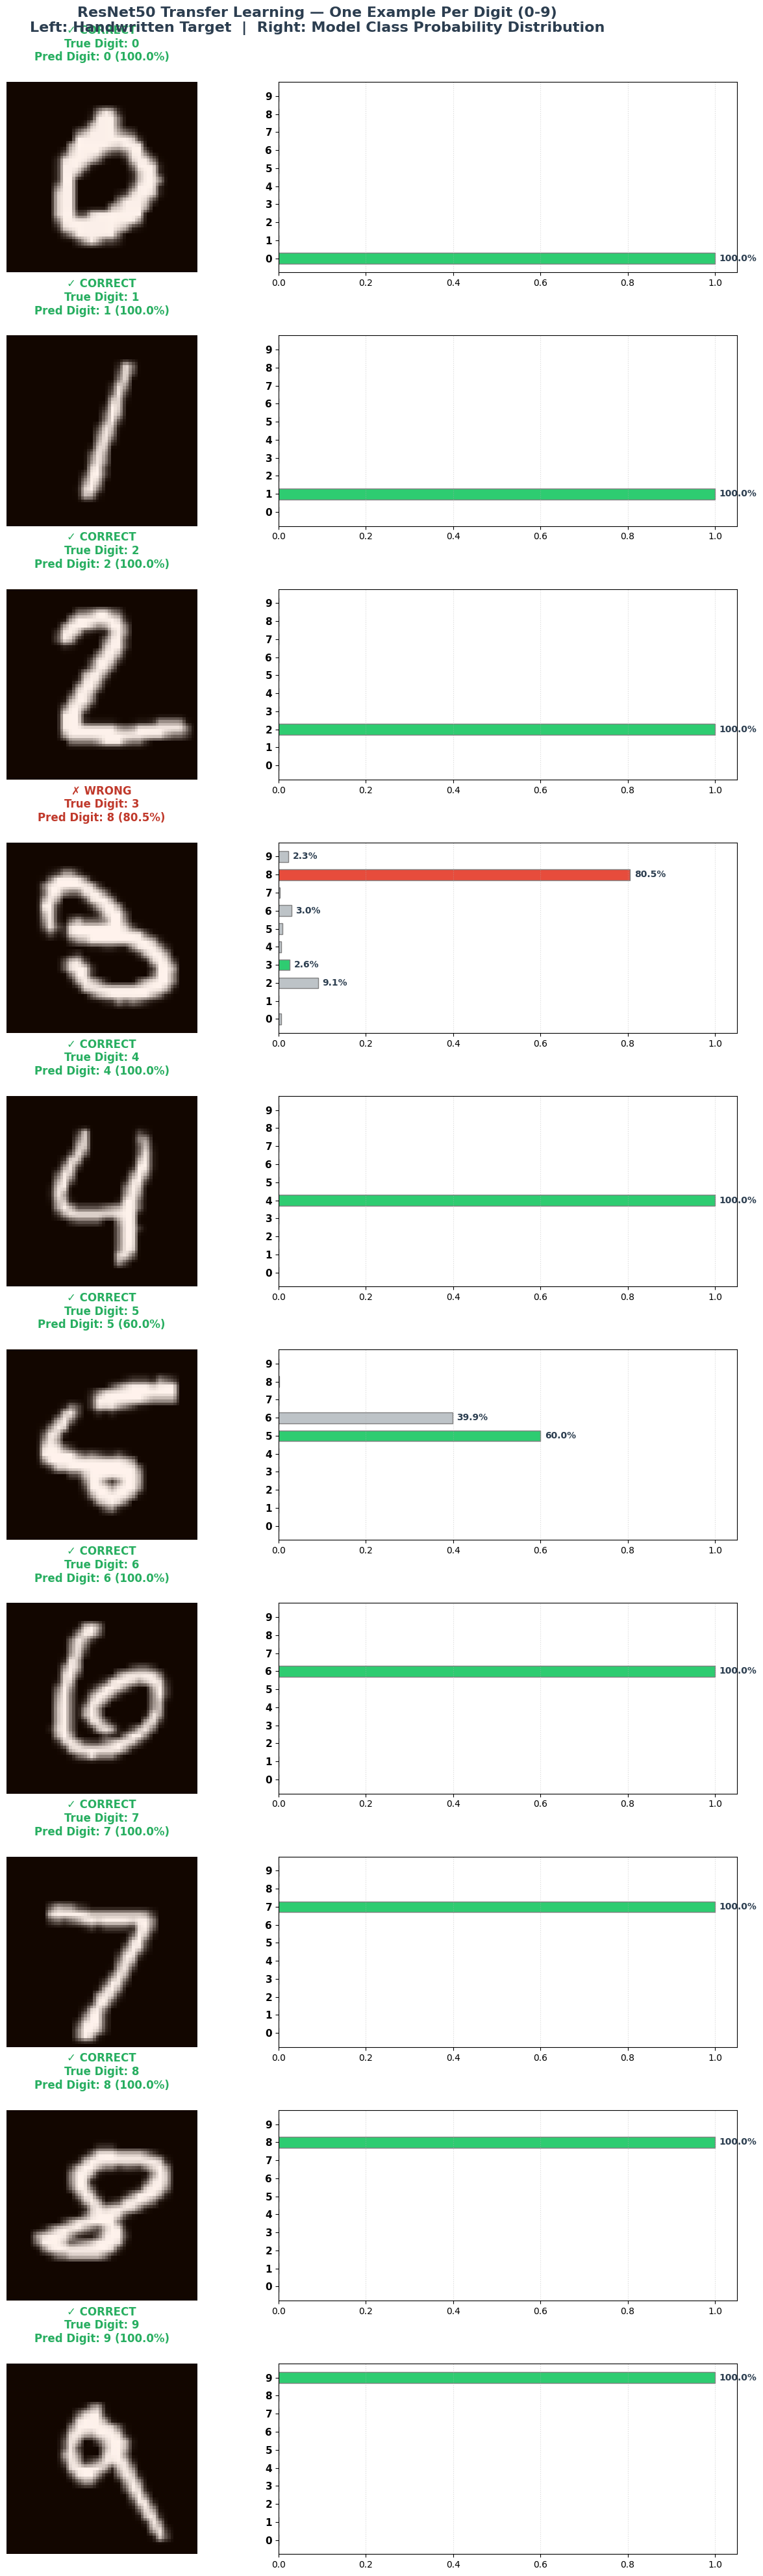

In [18]:
plot_one_of_each_digit(model=model, test_dataset=test_dataset)

In [19]:
# Save the complete model (Architecture + Weights + Optimizer state)
model.save('resnet50_mnist_98percent.keras')
print("✅ Model successfully saved to disk as 'resnet50_mnist_98percent.keras'!")

✅ Model successfully saved to disk as 'resnet50_mnist_98percent.keras'!
